## Running Jupyter Notebook with Hadoop and Spark

### MTI850 – Analytiques des données massives

### Alessandro L. Koerich

#### Ver. 1.0 – 31/08/2020

### Imports

In [1]:
import findspark
findspark.init()

In [2]:
import pyspark
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession, SQLContext

### Create a Spark Session

In [3]:
spark = SparkSession.builder.master("local").appName("Word Count").config("spark.some.config.option", "some-value").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/12 15:37:23 WARN Utils: Your hostname, localhost, resolves to a loopback address: 127.0.0.1; using 172.21.0.2 instead (on interface eth0)
26/09/12 15:37:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/spark/python/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/12 15:37:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Create a Python List and a DataFrame

In [4]:
from pyspark.sql import Row
data = [('Alice', 1), ('Bob', 2), ('Bill', 4)]
df = spark.createDataFrame(data, ['name', 'age'])
fil = df.filter(df.age > 3).collect()
print (fil)

[Stage 0:>                                                          (0 + 1) / 1]

[Row(name='Bill', age=4)]


### Create a Dataframe from a Text File stored in HDFS 

In [5]:
dataDF = spark.read.text("hdfs://localhost:9000/100-0.txt")

In [6]:
dataDF

DataFrame[value: string]

### Count the Number of Words in DataFrame

In [7]:
WordCount = dataDF.count()

In [8]:
print (WordCount)

196022


### Check if Matplotlib is Working

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import log

In [10]:
# function for generating plot layout
def preparePlot(xticks, yticks, figsize=(10.5, 6), hideLabels=False, gridColor='#999999', gridWidth=1.0):
    plt.close()
    fig, ax = plt.subplots(figsize=figsize, facecolor='white', edgecolor='white')
    ax.axes.tick_params(labelcolor='#999999', labelsize='10')
    for axis, ticks in [(ax.get_xaxis(), xticks), (ax.get_yaxis(), yticks)]:
        axis.set_ticks_position('none')
        axis.set_ticks(ticks)
        axis.label.set_color('#999999')
        if hideLabels: axis.set_ticklabels([])
    plt.grid(color=gridColor, linewidth=gridWidth, linestyle='-')
    map(lambda position: ax.spines[position].set_visible(False), ['bottom', 'top', 'left', 'right'])
    return fig, ax


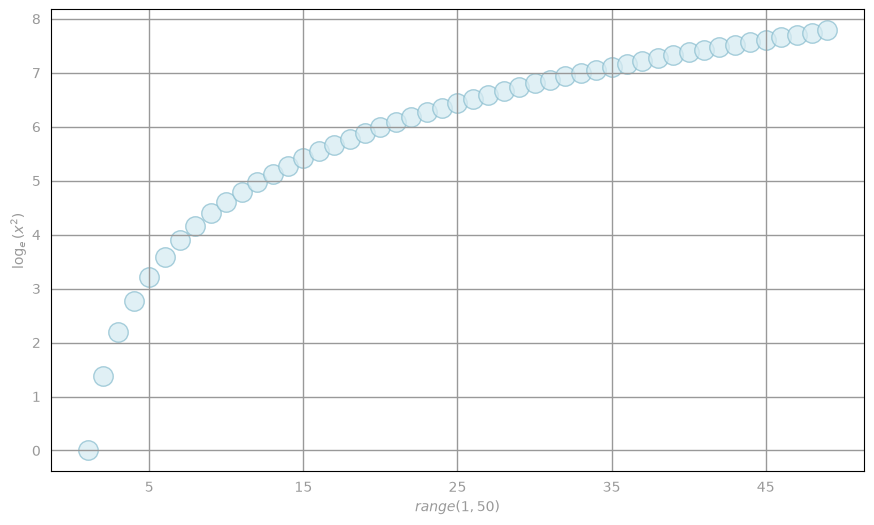

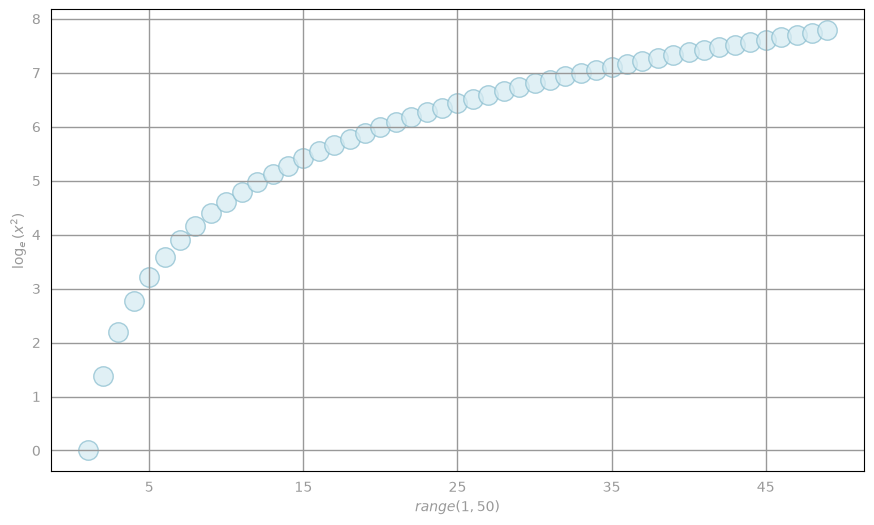

In [11]:
# generate layout and plot data
x = range(1, 50)
y = [log(x1 ** 2) for x1 in x]
fig, ax = preparePlot(range(5, 60, 10), range(0, 12, 1))
plt.scatter(x, y, s=14**2, c='#d6ebf2', edgecolors='#8cbfd0', alpha=0.75)
ax.set_xlabel(r'$range(1, 50)$'), ax.set_ylabel(r'$\log_e(x^2)$')
display(fig)
pass

### Check MathJax formulas

\\[ \scriptsize \mathbf{w}_{i+1} = \mathbf{w}_i - \alpha_i \sum_j (\mathbf{w}_i^\top\mathbf{x}_j  - y_j) \mathbf{x}_j \,\\]

\\( \scriptsize (\mathbf{w}^\top \mathbf{x} - y) \mathbf{x} \\)

\\[  \scriptsize \ell_{log}(p, y) = \begin{cases} -\log (p) & \text{if } y = 1 \\\ -\log(1-p) & \text{if } y = 0 \end{cases} \\]

### If you finish without errors, your VM looks good!